In [1]:
# dyslex_probe_bloom.ipynb

from unsloth import FastLanguageModel
import torch, numpy as np, pandas as pd
from tqdm import tqdm
from pathlib import Path

MODEL_ID = "bigscience/bloom-7b1"

# Try unsloth first
try:
    model, tok = FastLanguageModel.from_pretrained(
        model_name=MODEL_ID,
        max_seq_length=512,
        dtype=None,
        load_in_4bit=True,
    )
    FastLanguageModel.for_inference(model)
    print("loaded via unsloth")
except Exception as e:
    print(f"unsloth failed: {e}\nfalling back to HF transformers")
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    tok = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=bnb,
        device_map="auto", output_hidden_states=True,
    )

model.eval()
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

print("layers:", len(model.transformer.h) if hasattr(model,'transformer') 
      else len(model.model.layers))
print("hidden:", model.config.hidden_size)
print("vocab:", tok.vocab_size)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.6: Fast Bloom patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 5060 Ti. Num GPUs = 1. Max memory: 15.469 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth failed: BloomForCausalLM does not support an attention implementation through torch.nn.functional.scaled_dot_product_attention yet. Please request the support for this architecture: https://github.com/huggingface/transformers/issues/28005. If you believe this 

Loading weights:   0%|          | 0/365 [00:00<?, ?it/s]

layers: 30
hidden: 4096
vocab: 250680


In [2]:
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import torch, numpy as np, pandas as pd
from tqdm import tqdm
from pathlib import Path

MODEL_ID = "bigscience/bloom-7b1"

# Try unsloth first
try:
    from unsloth import FastLanguageModel
    model, tok = FastLanguageModel.from_pretrained(
        model_name=MODEL_ID,
        max_seq_length=512,
        dtype=None,
        load_in_4bit=True,
    )
    FastLanguageModel.for_inference(model)
    print("loaded via unsloth ✓")
except Exception as e:
    print(f"unsloth failed: {type(e).__name__}: {e}")
    print("falling back to HF transformers...")
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    tok = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb,
        device_map="auto",
        output_hidden_states=True,
    )
    print("loaded via HF ✓")

model.eval()
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

# Inspect structure
print("hidden:", model.config.hidden_size)
print("vocab:", tok.vocab_size)
print("n_layers:", model.config.n_layer if hasattr(model.config,'n_layer')
      else model.config.num_hidden_layers)

# Detect layer path (BLOOM differs from Llama)
if hasattr(model, 'transformer'):
    print("layer path: model.transformer.h[i]")
elif hasattr(model, 'model'):
    print("layer path: model.model.layers[i]")

==((====))==  Unsloth 2026.5.6: Fast Bloom patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 5060 Ti. Num GPUs = 1. Max memory: 15.469 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth failed: ValueError: BloomForCausalLM does not support an attention implementation through torch.nn.functional.scaled_dot_product_attention yet. Please request the support for this architecture: https://github.com/huggingface/transformers/issues/28005. If you believe this error is a bug, please open an issue in Transformers GitHub repository and load your model with the argument `attn_implementation="eager"` meanwhile. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="eager")`
falli

Loading weights:   0%|          | 0/365 [00:00<?, ?it/s]

loaded via HF ✓
hidden: 4096
vocab: 250680
n_layers: 30
layer path: model.transformer.h[i]


In [3]:
# Pad token
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

# Check BOS behavior
test = tok("cat", return_tensors="pt")
print("tokens:", test.input_ids[0].tolist())
print("decoded:", [tok.decode([t]) for t in test.input_ids[0]])
print("bos_token:", tok.bos_token, "id:", tok.bos_token_id)

tokens: [14292]
decoded: ['cat']
bos_token: <s> id: 1


In [4]:
def extract_representation(text, model, tokenizer, device):
    inputs = tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=512,
        add_special_tokens=True,  # BLOOM still respects this
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states  # 31 tensors
    attention_mask = inputs["attention_mask"][0]

    # BLOOM: no BOS prepended, no EOS appended → all tokens are content
    content_mask = attention_mask.clone()

    pooled_layers = []
    for layer_hidden in hidden_states:
        layer = layer_hidden[0].float()
        masked = layer * content_mask.unsqueeze(-1).float()
        pooled = masked.sum(dim=0) / content_mask.sum().clamp(min=1).float()
        pooled_layers.append(pooled.cpu().numpy())

    return np.stack(pooled_layers)  # (31, 4096)

In [5]:
for t in ["cat", "bat", "বিড়াল", "বাদুড়", "The boy reads a book."]:
    rep = extract_representation(t, model, tok, "cuda")
    print(t, rep.shape, "nan:", np.isnan(rep).any(),
          f"range: {rep.min():.2f} {rep.max():.2f}")

cat (31, 4096) nan: False range: -3900.00 246.25
bat (31, 4096) nan: False range: -3736.00 245.75
বিড়াল (31, 4096) nan: False range: -1184.72 555.75
বাদুড় (31, 4096) nan: False range: -1790.80 550.88
The boy reads a book. (31, 4096) nan: False range: -582.94 233.08


In [6]:
rep = extract_representation("cat", model, tok, "cuda")
for L in [0, 5, 10, 15, 20, 25, 30]:
    print(f"L{L:2d}: min={rep[L].min():.2f}  max={rep[L].max():.2f}  mean={rep[L].mean():.2f}  std={rep[L].std():.2f}")

L 0: min=-2.24  max=3.12  mean=0.00  std=0.54
L 5: min=-34.44  max=123.56  mean=0.02  std=3.03
L10: min=-3646.00  max=135.25  mean=-0.73  std=57.05
L15: min=-3898.00  max=130.88  mean=-0.74  std=60.98
L20: min=-3888.00  max=142.00  mean=-0.75  std=60.83
L25: min=-3786.00  max=195.00  mean=-0.84  std=59.28
L30: min=-223.62  max=129.25  mean=-0.08  std=6.91


In [7]:
rep = extract_representation("cat", model, tok, "cuda")
L = 15
abs_vals = np.abs(rep[L])
top5 = np.argsort(abs_vals)[-5:][::-1]
print(f"Top 5 outlier dims at L15:")
for d in top5:
    print(f"  dim {d}: {rep[L, d]:.2f}")
print(f"99th percentile abs: {np.percentile(abs_vals, 99):.2f}")
print(f"95th percentile abs: {np.percentile(abs_vals, 95):.2f}")

Top 5 outlier dims at L15:
  dim 1947: -3898.00
  dim 3448: 130.88
  dim 2581: 90.31
  dim 3279: -49.66
  dim 2719: 36.19
99th percentile abs: 3.96
95th percentile abs: 2.50


In [8]:
REPS_DIR = Path("representations")
REPS_DIR.mkdir(exist_ok=True)

df = pd.read_csv("dyslex_probe_stimuli_clean.csv")
en_df = df[df['language']=='english'].reset_index(drop=True)
bn_df = df[df['language']=='bangla'].reset_index(drop=True)

def extract_split(df_split, name):
    reps = []
    for text in tqdm(df_split['word'].tolist(), desc=name):
        rep = extract_representation(text, model, tok, "cuda")
        reps.append(rep)
    return np.stack(reps)

en_reps = extract_split(en_df, "english")
bn_reps = extract_split(bn_df, "bangla")

np.save(REPS_DIR / "bloom_english_reps.npy", en_reps)
np.save(REPS_DIR / "bloom_bangla_reps.npy", bn_reps)
en_df.to_csv(REPS_DIR / "bloom_english_meta.csv", index=False)
bn_df.to_csv(REPS_DIR / "bloom_bangla_meta.csv", index=False)

print("EN:", en_reps.shape, "BN:", bn_reps.shape)
print("EN nan:", np.isnan(en_reps).any(), "BN nan:", np.isnan(bn_reps).any())

bangla: 100%|██████████| 220/220 [00:25<00:00,  8.65it/s]


EN: (220, 31, 4096) BN: (220, 31, 4096)
EN nan: False BN nan: False


In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import f1_score, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

en_reps = np.load("representations/bloom_english_reps.npy")
en_meta = pd.read_csv("representations/bloom_english_meta.csv")
N_LAYERS = en_reps.shape[1]

def probe_binary(X_layers, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    out = []
    for L in range(X_layers.shape[1]):
        X = X_layers[:, L, :]
        f1s = []
        for tr, te in skf.split(X, y):
            clf = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=1000, C=1.0, solver='liblinear')
            )
            clf.fit(X[tr], y[tr])
            f1s.append(f1_score(y[te], clf.predict(X[te]), average="macro"))
        out.append(np.mean(f1s))
    return np.array(out)

def probe_regression(X_layers, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    out = []
    for L in range(X_layers.shape[1]):
        X = X_layers[:, L, :]
        r2s = []
        for tr, te in kf.split(X):
            reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            reg.fit(X[tr], y[tr])
            r2s.append(r2_score(y[te], reg.predict(X[te])))
        out.append(np.mean(r2s))
    return np.array(out)

# voicing
m = en_meta['voiced_unvoiced'].isin(['voiced','unvoiced'])
y = (en_meta.loc[m,'voiced_unvoiced']=='voiced').astype(int).values
v = probe_binary(en_reps[m.values], y)
print(f"voicing  n={m.sum()} peak L{v.argmax()} F1={v.max():.3f}")

# real word
m = en_meta['is_real_word'].notna()
y = en_meta.loc[m,'is_real_word'].astype(str).map({'True':1,'False':0}).values
r = probe_binary(en_reps[m.values], y)
print(f"realword n={m.sum()} peak L{r.argmax()} F1={r.max():.3f}")

# ortho
m = en_meta['orthographic_transparency'].isin(['transparent','opaque'])
y = (en_meta.loc[m,'orthographic_transparency']=='transparent').astype(int).values
o = probe_binary(en_reps[m.values], y)
print(f"ortho    n={m.sum()} peak L{o.argmax()} F1={o.max():.3f}")

# syllable
m = en_meta['syllable_count'].notna() & (en_meta['task_category']!='sentence')
y = en_meta.loc[m,'syllable_count'].astype(float).values
s = probe_regression(en_reps[m.values], y)
print(f"syllable n={m.sum()} peak L{s.argmax()} R²={s.max():.3f}")

pd.DataFrame({
    'layer': range(N_LAYERS),
    'f1_voicing': v, 'f1_realword': r, 'f1_ortho': o, 'r2_syllable': s,
}).to_csv("results_english_probing_bloom.csv", index=False)
print("saved.")

voicing  n=30 peak L6 F1=0.552
realword n=220 peak L22 F1=0.787
ortho    n=220 peak L12 F1=0.681
syllable n=205 peak L29 R²=0.679
saved.


In [11]:
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, r2_score

en_reps = np.load("representations/bloom_english_reps.npy")
bn_reps = np.load("representations/bloom_bangla_reps.npy")
en_meta = pd.read_csv("representations/bloom_english_meta.csv")
bn_meta = pd.read_csv("representations/bloom_bangla_meta.csv")
N_LAYERS = en_reps.shape[1]

# Bangla voicing fix
voiced_starters = {'গ','ব','দ','ড','জ','ঘ','ভ','ধ','ঢ','ঝ'}
unvoiced_starters = {'ক','প','ত','ট','চ','খ','ফ','থ','ঠ','ছ'}
def infer_bn_voicing(row):
    if row['error_type_targeted'] not in ('voiced_unvoiced_confusion','aspiration_confusion'):
        return row['voiced_unvoiced']
    fc = str(row['word'])[0]
    if fc in voiced_starters: return 'voiced'
    if fc in unvoiced_starters: return 'unvoiced'
    return 'na'
bn_meta['voiced_unvoiced'] = bn_meta.apply(infer_bn_voicing, axis=1)

def transfer_binary(X_en, y_en, X_bn, y_bn):
    en_f1, bn_f1 = [], []
    for L in range(X_en.shape[1]):
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=1000, C=1.0, solver='liblinear'))
        clf.fit(X_en[:, L, :], y_en)
        en_f1.append(f1_score(y_en, clf.predict(X_en[:, L, :]), average="macro"))
        bn_f1.append(f1_score(y_bn, clf.predict(X_bn[:, L, :]), average="macro"))
    return np.array(en_f1), np.array(bn_f1)

def transfer_regression(X_en, y_en, X_bn, y_bn):
    en_r2, bn_r2 = [], []
    for L in range(X_en.shape[1]):
        reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        reg.fit(X_en[:, L, :], y_en)
        en_r2.append(r2_score(y_en, reg.predict(X_en[:, L, :])))
        bn_r2.append(r2_score(y_bn, reg.predict(X_bn[:, L, :])))
    return np.array(en_r2), np.array(bn_r2)

# voicing
em = en_meta['voiced_unvoiced'].isin(['voiced','unvoiced'])
bm = bn_meta['voiced_unvoiced'].isin(['voiced','unvoiced'])
ye = (en_meta.loc[em,'voiced_unvoiced']=='voiced').astype(int).values
yb = (bn_meta.loc[bm,'voiced_unvoiced']=='voiced').astype(int).values
ev, bv = transfer_binary(en_reps[em.values], ye, bn_reps[bm.values], yb)
print(f"voicing  EN best {ev.max():.3f}  BN best L{bv.argmax()} {bv.max():.3f}  ratio {bv.max()/ev.max():.2f}")

# real word
em = en_meta['is_real_word'].notna()
bm = bn_meta['is_real_word'].notna()
ye = en_meta.loc[em,'is_real_word'].astype(str).map({'True':1,'False':0}).values
yb = bn_meta.loc[bm,'is_real_word'].astype(str).map({'True':1,'False':0}).values
er, br = transfer_binary(en_reps[em.values], ye, bn_reps[bm.values], yb)
print(f"realword EN best {er.max():.3f}  BN best L{br.argmax()} {br.max():.3f}  ratio {br.max()/er.max():.2f}")

# syllable
em = en_meta['syllable_count'].notna() & (en_meta['task_category']!='sentence')
bm = bn_meta['syllable_count'].notna() & (bn_meta['task_category']!='sentence')
ye = en_meta.loc[em,'syllable_count'].astype(float).values
yb = bn_meta.loc[bm,'syllable_count'].astype(float).values
es, bs = transfer_regression(en_reps[em.values], ye, bn_reps[bm.values], yb)
print(f"syllable EN best {es.max():.3f}  BN best L{bs.argmax()} {bs.max():.3f}  ratio {bs.max()/es.max():.2f}")

pd.DataFrame({
    'layer': range(N_LAYERS),
    'en_voicing': ev, 'bn_voicing': bv,
    'en_realword': er, 'bn_realword': br,
    'en_syllable': es, 'bn_syllable': bs,
}).to_csv("results_transfer_bloom.csv", index=False)

voicing  EN best 1.000  BN best L1 0.695  ratio 0.70
realword EN best 1.000  BN best L5 0.720  ratio 0.72
syllable EN best 1.000  BN best L18 0.565  ratio 0.56


In [12]:
# Bangla voicing fix
voiced_starters = {'গ','ব','দ','ড','জ','ঘ','ভ','ধ','ঢ','ঝ'}
unvoiced_starters = {'ক','প','ত','ট','চ','খ','ফ','থ','ঠ','ছ'}

def infer_bn_voicing(row):
    if row['error_type_targeted'] not in ('voiced_unvoiced_confusion','aspiration_confusion'):
        return row['voiced_unvoiced']
    fc = str(row['word'])[0]
    if fc in voiced_starters: return 'voiced'
    if fc in unvoiced_starters: return 'unvoiced'
    return 'na'

bn_meta['voiced_unvoiced'] = bn_meta.apply(infer_bn_voicing, axis=1)
print(bn_meta['voiced_unvoiced'].value_counts())

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def transfer_binary(X_en, y_en, X_bn, y_bn):
    en_f1, bn_f1 = [], []
    for L in range(X_en.shape[1]):
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=1000, C=1.0, solver='liblinear'))
        clf.fit(X_en[:, L, :], y_en)
        en_f1.append(f1_score(y_en, clf.predict(X_en[:, L, :]), average="macro"))
        bn_f1.append(f1_score(y_bn, clf.predict(X_bn[:, L, :]), average="macro"))
    return np.array(en_f1), np.array(bn_f1)

def transfer_regression(X_en, y_en, X_bn, y_bn):
    en_r2, bn_r2 = [], []
    for L in range(X_en.shape[1]):
        reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        reg.fit(X_en[:, L, :], y_en)
        en_r2.append(r2_score(y_en, reg.predict(X_en[:, L, :])))
        bn_r2.append(r2_score(y_bn, reg.predict(X_bn[:, L, :])))
    return np.array(en_r2), np.array(bn_r2)

# voicing
em = en_meta['voiced_unvoiced'].isin(['voiced','unvoiced'])
bm = bn_meta['voiced_unvoiced'].isin(['voiced','unvoiced'])
ye = (en_meta.loc[em,'voiced_unvoiced']=='voiced').astype(int).values
yb = (bn_meta.loc[bm,'voiced_unvoiced']=='voiced').astype(int).values
ev, bv = transfer_binary(en_reps[em.values], ye, bn_reps[bm.values], yb)
print(f"voicing  EN best {ev.max():.3f}  BN best L{bv.argmax()} {bv.max():.3f}  ratio {bv.max()/ev.max():.2f}")

# real word
em = en_meta['is_real_word'].notna()
bm = bn_meta['is_real_word'].notna()
ye = en_meta.loc[em,'is_real_word'].astype(str).map({'True':1,'False':0}).values
yb = bn_meta.loc[bm,'is_real_word'].astype(str).map({'True':1,'False':0}).values
er, br = transfer_binary(en_reps[em.values], ye, bn_reps[bm.values], yb)
print(f"realword EN best {er.max():.3f}  BN best L{br.argmax()} {br.max():.3f}  ratio {br.max()/er.max():.2f}")

# syllable
em = en_meta['syllable_count'].notna() & (en_meta['task_category']!='sentence')
bm = bn_meta['syllable_count'].notna() & (bn_meta['task_category']!='sentence')
ye = en_meta.loc[em,'syllable_count'].astype(float).values
yb = bn_meta.loc[bm,'syllable_count'].astype(float).values
es, bs = transfer_regression(en_reps[em.values], ye, bn_reps[bm.values], yb)
print(f"syllable EN best {es.max():.3f}  BN best L{bs.argmax()} {bs.max():.3f}  ratio {bs.max()/es.max():.2f}")

pd.DataFrame({
    'layer': range(N_LAYERS),
    'en_voicing': ev, 'bn_voicing': bv,
    'en_realword': er, 'bn_realword': br,
    'en_syllable': es, 'bn_syllable': bs,
}).to_csv("results_transfer_bloom.csv", index=False)

voiced_unvoiced
na          174
unvoiced     23
voiced       23
Name: count, dtype: int64
voicing  EN best 1.000  BN best L1 0.695  ratio 0.70
realword EN best 1.000  BN best L5 0.720  ratio 0.72
syllable EN best 1.000  BN best L18 0.565  ratio 0.56


In [13]:
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity

en_cp = en_meta[en_meta['task_category']=='concept_match'].copy()
bn_cp = bn_meta[bn_meta['task_category']=='concept_match'].copy()
en_cp = en_cp.sort_values('matched_pair_id').reset_index()
bn_cp = bn_cp.sort_values('matched_pair_id').reset_index()
assert (en_cp['matched_pair_id'].values == bn_cp['matched_pair_id'].values).all()
print(f"concept pairs: {len(en_cp)}")

en_cp_reps = en_reps[en_cp['index'].values]
bn_cp_reps = bn_reps[bn_cp['index'].values]

rsa_corr, top1_align = [], []
for L in range(N_LAYERS):
    en_L = en_cp_reps[:, L, :]
    bn_L = bn_cp_reps[:, L, :]
    en_sim = cosine_similarity(en_L)
    bn_sim = cosine_similarity(bn_L)
    iu = np.triu_indices_from(en_sim, k=1)
    rho, _ = spearmanr(en_sim[iu], bn_sim[iu])
    rsa_corr.append(rho)
    cross = cosine_similarity(en_L, bn_L)
    pred = cross.argmax(axis=1)
    top1_align.append((pred == np.arange(len(en_L))).mean())

rsa_corr = np.array(rsa_corr)
top1_align = np.array(top1_align)

print(f"RDM   peak L{rsa_corr.argmax()} ρ={rsa_corr.max():.3f}")
print(f"Top-1 peak L{top1_align.argmax()} acc={top1_align.max():.3f}  (chance={1/len(en_cp):.3f})")

pd.DataFrame({
    'layer': range(N_LAYERS),
    'rdm_spearman': rsa_corr,
    'top1_alignment': top1_align,
}).to_csv("results_rsa_bloom.csv", index=False)

concept pairs: 20
RDM   peak L3 ρ=0.208
Top-1 peak L4 acc=0.650  (chance=0.050)


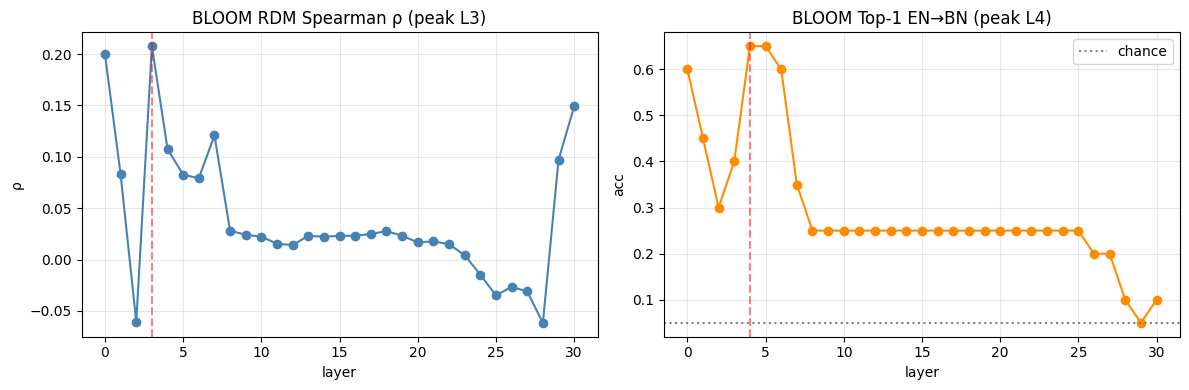

In [14]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(N_LAYERS), rsa_corr, marker='o', color='steelblue')
axes[0].axvline(rsa_corr.argmax(), ls='--', color='red', alpha=0.5)
axes[0].set_title(f"BLOOM RDM Spearman ρ (peak L{rsa_corr.argmax()})")
axes[0].set_xlabel("layer"); axes[0].set_ylabel("ρ"); axes[0].grid(alpha=0.3)
axes[1].plot(range(N_LAYERS), top1_align, marker='o', color='darkorange')
axes[1].axhline(0.05, ls=':', color='gray', label='chance')
axes[1].axvline(top1_align.argmax(), ls='--', color='red', alpha=0.5)
axes[1].set_title(f"BLOOM Top-1 EN→BN (peak L{top1_align.argmax()})")
axes[1].set_xlabel("layer"); axes[1].set_ylabel("acc"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots_rsa_bloom.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# BLOOM-specific task config
TASKS_BLOOM = {
    "voicing":  {"ablate_L": 4,  "measure_L": 6,  "kind": "binary",
                 "mask": en_meta['voiced_unvoiced'].isin(['voiced','unvoiced']).values,
                 "y": (en_meta.loc[en_meta['voiced_unvoiced'].isin(['voiced','unvoiced']),
                                   'voiced_unvoiced']=='voiced').astype(int).values},
    "realword": {"ablate_L": 20, "measure_L": 22, "kind": "binary",
                 "mask": en_meta['is_real_word'].notna().values,
                 "y": en_meta.loc[en_meta['is_real_word'].notna(),
                                  'is_real_word'].astype(str).map({'True':1,'False':0}).values},
    "syllable": {"ablate_L": 27, "measure_L": 29, "kind": "regression",
                 "mask": (en_meta['syllable_count'].notna() &
                          (en_meta['task_category']!='sentence')).values,
                 "y": en_meta.loc[(en_meta['syllable_count'].notna() &
                                   (en_meta['task_category']!='sentence')),
                                  'syllable_count'].astype(float).values},
}

# rank phon-important units per task
task_ranked = {}
for name, t in TASKS_BLOOM.items():
    X = en_reps[t["mask"], t["ablate_L"], :]
    Xs = StandardScaler().fit(X)
    Xn = Xs.transform(X)
    if t["kind"] == "binary":
        probe = LogisticRegression(max_iter=2000, C=1.0, solver='liblinear').fit(Xn, t["y"])
        imp = np.abs(probe.coef_[0])
    else:
        probe = Ridge(alpha=1.0).fit(Xn, t["y"])
        imp = np.abs(probe.coef_)
    ranked = np.argsort(imp)[::-1].copy()
    task_ranked[name] = ranked
    print(f"{name}: ablate L{t['ablate_L']}  top-10 imp range "
          f"{imp[ranked[:10]].min():.3f} to {imp[ranked[:10]].max():.3f}")

np.save("representations/bloom_task_ranked_units.npy", task_ranked, allow_pickle=True)

voicing: ablate L4  top-10 imp range 0.026 to 0.030
realword: ablate L20  top-10 imp range 0.109 to 0.141
syllable: ablate L27  top-10 imp range 0.008 to 0.009


In [16]:
def extract_with_ablation(text, model, tokenizer, device,
                          ablate_layer=None, ablate_units=None):
    hook_handle = None
    if ablate_layer is not None and ablate_units is not None:
        units_t = torch.tensor(ablate_units, dtype=torch.long, device=device)
        def hook_fn(module, inp, output):
            if isinstance(output, tuple):
                hidden = output[0].clone()
                hidden[:, :, units_t] = 0.0
                return (hidden,) + output[1:]
            else:
                hidden = output.clone()
                hidden[:, :, units_t] = 0.0
                return hidden
        # BLOOM: model.transformer.h[i]
        hook_handle = model.transformer.h[ablate_layer].register_forward_hook(hook_fn)

    try:
        inputs = tokenizer(text, return_tensors="pt",
                           truncation=True, max_length=512,
                           add_special_tokens=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states
        attention_mask = inputs["attention_mask"][0]
        content_mask = attention_mask.clone()  # no BOS to exclude in BLOOM
        pooled_layers = []
        for layer_hidden in hidden_states:
            layer = layer_hidden[0].float()
            masked = layer * content_mask.unsqueeze(-1).float()
            pooled = masked.sum(dim=0) / content_mask.sum().clamp(min=1).float()
            pooled_layers.append(pooled.cpu().numpy())
        return np.stack(pooled_layers)
    finally:
        if hook_handle is not None:
            hook_handle.remove()

# Extract all conditions
np.random.seed(42)
random_units_per_task = {name: np.random.choice(4096, size=10, replace=False)
                         for name in TASKS_BLOOM}

for task_name, t in TASKS_BLOOM.items():
    ranked = task_ranked[task_name]
    conditions = {
        "top5":  ranked[:5].tolist(),
        "top10": ranked[:10].tolist(),
        "top20": ranked[:20].tolist(),
        "rand10": random_units_per_task[task_name].tolist(),
    }
    for cond_name, units in conditions.items():
        for lang_name, df_split in [("english", en_df), ("bangla", bn_df)]:
            reps = []
            for text in tqdm(df_split['word'].tolist(),
                             desc=f"{task_name}_{cond_name}_{lang_name}"):
                rep = extract_with_ablation(
                    text, model, tok, "cuda",
                    ablate_layer=t["ablate_L"],
                    ablate_units=units
                )
                reps.append(rep)
            arr = np.stack(reps)
            np.save(f"representations/bloom_{task_name}_{cond_name}_{lang_name}.npy", arr)
            print(f"saved bloom_{task_name}_{cond_name}_{lang_name}: {arr.shape}")

voicing_top5_english: 100%|██████████| 220/220 [00:20<00:00, 10.82it/s]


saved bloom_voicing_top5_english: (220, 31, 4096)


voicing_top5_bangla: 100%|██████████| 220/220 [00:25<00:00,  8.65it/s]


saved bloom_voicing_top5_bangla: (220, 31, 4096)


voicing_top10_english: 100%|██████████| 220/220 [00:20<00:00, 10.88it/s]


...

saved bloom_syllable_top20_bangla: (220, 31, 4096)


syllable_rand10_english: 100%|██████████| 220/220 [00:20<00:00, 10.95it/s]


saved bloom_syllable_rand10_english: (220, 31, 4096)


syllable_rand10_bangla: 100%|██████████| 220/220 [00:25<00:00,  8.59it/s]


saved bloom_syllable_rand10_bangla: (220, 31, 4096)


In [17]:
from sklearn.model_selection import StratifiedKFold, KFold

def eval_binary_cv(train_X, train_y, eval_X, eval_y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr, _ in skf.split(train_X, train_y):
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=1000, C=1.0, solver='liblinear'))
        clf.fit(train_X[tr], train_y[tr])
        scores.append(f1_score(eval_y, clf.predict(eval_X), average="macro"))
    return np.mean(scores)

def eval_reg_cv(train_X, train_y, eval_X, eval_y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr, _ in kf.split(train_X):
        reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        reg.fit(train_X[tr], train_y[tr])
        scores.append(r2_score(eval_y, reg.predict(eval_X)))
    return np.mean(scores)

BN_LABELS = {
    "voicing": {
        "mask": bn_meta['voiced_unvoiced'].isin(['voiced','unvoiced']).values,
        "y": (bn_meta.loc[bn_meta['voiced_unvoiced'].isin(['voiced','unvoiced']),
                          'voiced_unvoiced']=='voiced').astype(int).values},
    "realword": {
        "mask": bn_meta['is_real_word'].notna().values,
        "y": bn_meta.loc[bn_meta['is_real_word'].notna(),
                         'is_real_word'].astype(str).map({'True':1,'False':0}).values},
    "syllable": {
        "mask": (bn_meta['syllable_count'].notna() &
                 (bn_meta['task_category']!='sentence')).values,
        "y": bn_meta.loc[(bn_meta['syllable_count'].notna() &
                          (bn_meta['task_category']!='sentence')),
                         'syllable_count'].astype(float).values},
}

rows = []
for task_name, t in TASKS_BLOOM.items():
    mL = t["measure_L"]
    en_mask, en_y = t["mask"], t["y"]
    bn_mask, bn_y = BN_LABELS[task_name]["mask"], BN_LABELS[task_name]["y"]
    eval_fn = eval_binary_cv if t["kind"] == "binary" else eval_reg_cv
    train_X = en_reps[en_mask, mL, :]
    train_y = en_y

    for cond in ["baseline","top5","top10","top20","rand10"]:
        if cond == "baseline":
            en_eval = en_reps[en_mask, mL, :]
            bn_eval = bn_reps[bn_mask, mL, :]
        else:
            en_arr = np.load(f"representations/bloom_{task_name}_{cond}_english.npy")
            bn_arr = np.load(f"representations/bloom_{task_name}_{cond}_bangla.npy")
            en_eval = en_arr[en_mask, mL, :]
            bn_eval = bn_arr[bn_mask, mL, :]

        en_score = eval_fn(train_X, train_y, en_eval, en_y)
        bn_score = eval_fn(train_X, train_y, bn_eval, bn_y)
        rows.append([task_name, cond, en_score, bn_score])

deg = pd.DataFrame(rows, columns=["task","condition","EN","BN"])
print(deg.to_string(index=False))
deg.to_csv("results_ablation_bloom_final.csv", index=False)

    task condition       EN       BN
 voicing  baseline 0.913222 0.534543
 voicing      top5 0.906413 0.534543
 voicing     top10 0.906413 0.523191
 voicing     top20 0.906413 0.523191
 voicing    rand10 0.906413 0.534543
realword  baseline 0.943035 0.628939
realword      top5 0.941089 0.626704
realword     top10 0.937565 0.617785
realword     top20 0.939452 0.620079
realword    rand10 0.943035 0.630480
syllable  baseline 0.934190 0.399207
syllable      top5 0.932127 0.400926
syllable     top10 0.930956 0.405938
syllable     top20 0.928941 0.398780
syllable    rand10 0.934246 0.403987


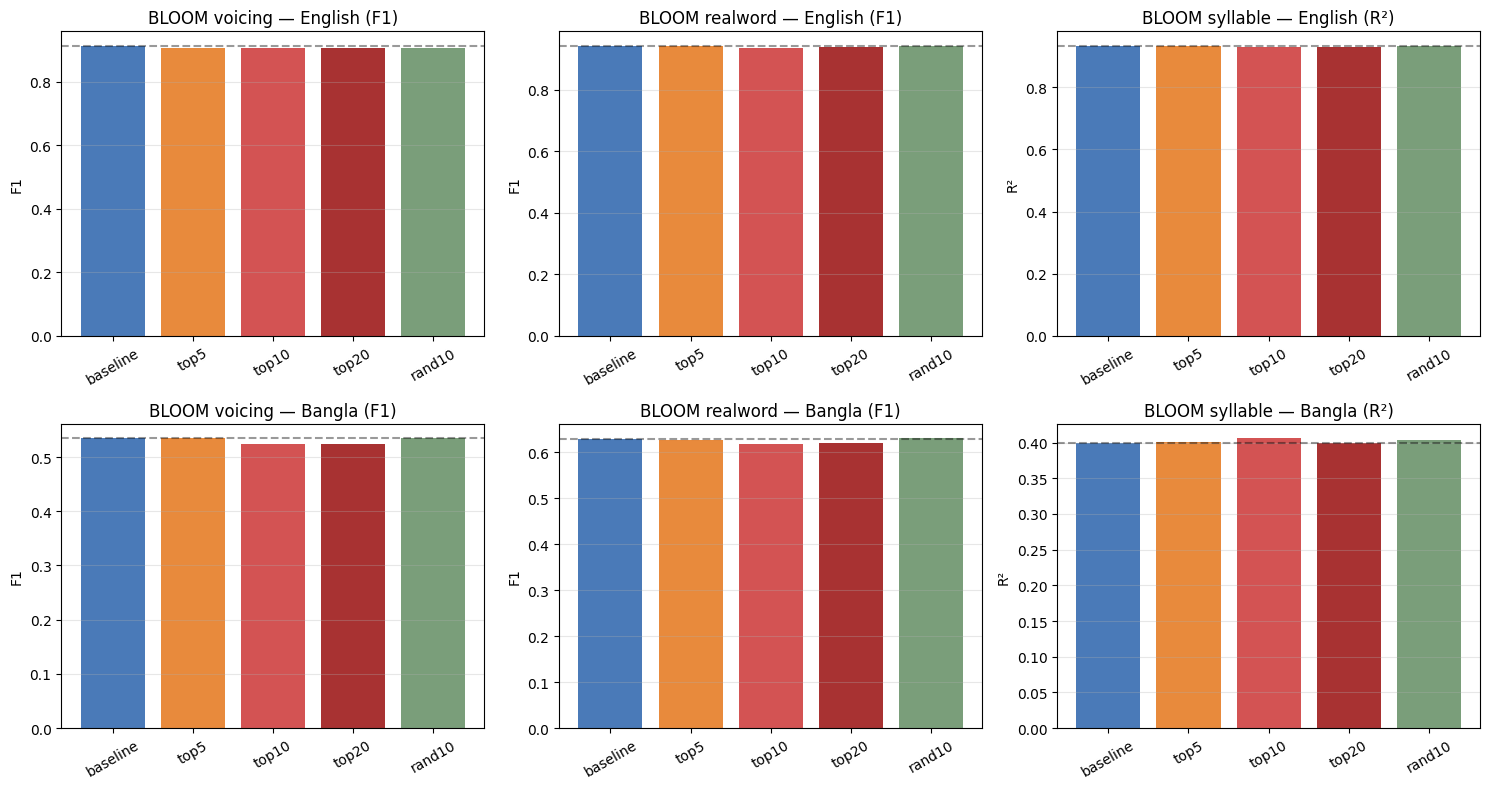

In [18]:
import matplotlib.pyplot as plt

deg = pd.read_csv("results_ablation_bloom_final.csv")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
order = ["baseline","top5","top10","top20","rand10"]
colors = ["#4a7ab8","#e88a3c","#d35353","#a83232","#7a9e7a"]

for col, task in enumerate(["voicing","realword","syllable"]):
    sub = deg[deg['task']==task].set_index('condition').loc[order]
    metric = "F1" if task != "syllable" else "R²"

    ax = axes[0, col]
    ax.bar(order, sub['EN'], color=colors)
    ax.set_title(f"BLOOM {task} — English ({metric})")
    ax.set_ylabel(metric); ax.grid(axis='y', alpha=0.3)
    ax.axhline(sub.loc['baseline','EN'], ls='--', color='black', alpha=0.4)
    ax.tick_params(axis='x', rotation=30)

    ax = axes[1, col]
    ax.bar(order, sub['BN'], color=colors)
    ax.set_title(f"BLOOM {task} — Bangla ({metric})")
    ax.set_ylabel(metric); ax.grid(axis='y', alpha=0.3)
    ax.axhline(sub.loc['baseline','BN'], ls='--', color='black', alpha=0.4)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("plots_ablation_bloom_final.png", dpi=150, bbox_inches='tight')
plt.show()

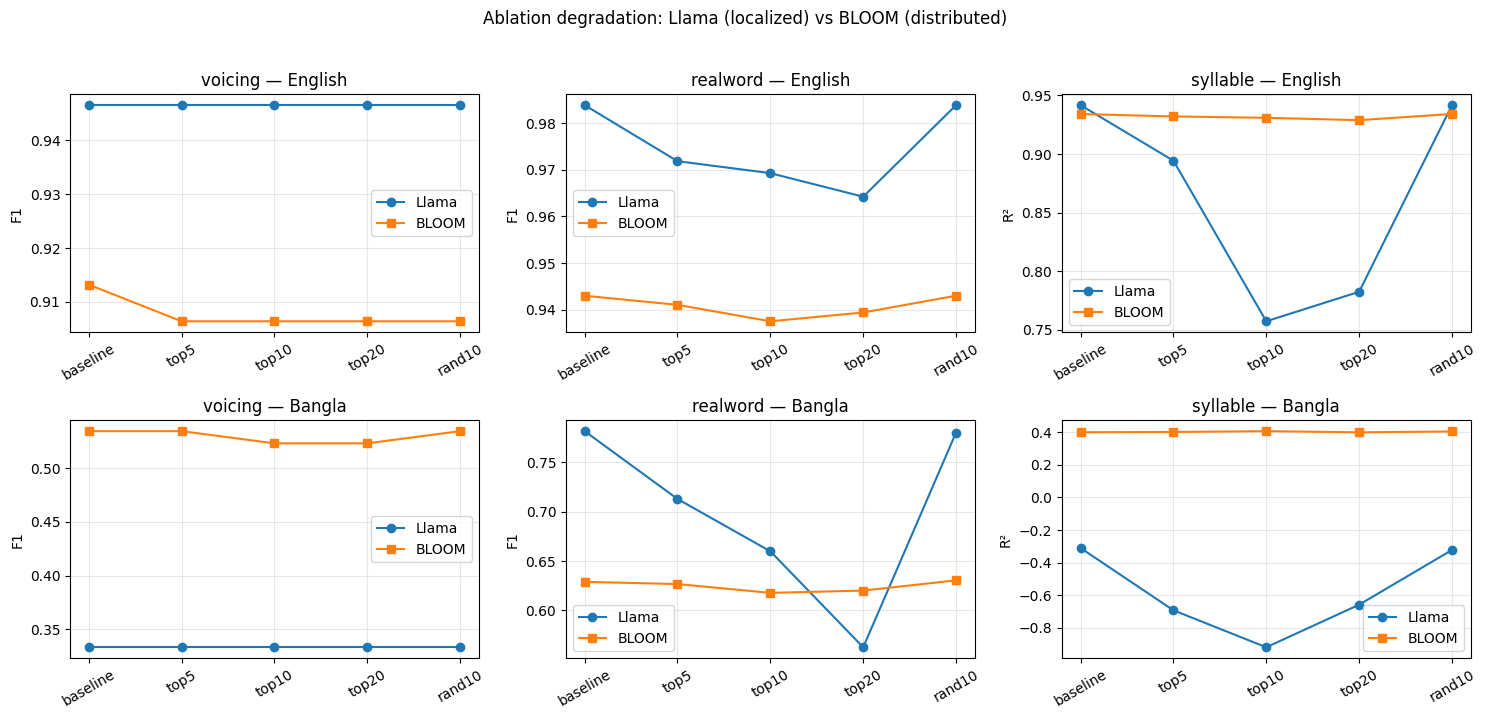

In [20]:
deg_llama = pd.read_csv("../dyslexia-LLM/results_ablation_llama_final.csv")
deg_bloom = pd.read_csv("results_ablation_bloom_final.csv")

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
x = ["baseline","top5","top10","top20","rand10"]

for col, task in enumerate(["voicing","realword","syllable"]):
    l = deg_llama[deg_llama['task']==task].set_index('condition').loc[x]
    b = deg_bloom[deg_bloom['task']==task].set_index('condition').loc[x]

    # EN row
    ax = axes[0, col]
    ax.plot(x, l['EN'], marker='o', color='#1f77b4', label='Llama')
    ax.plot(x, b['EN'], marker='s', color='#ff7f0e', label='BLOOM')
    ax.set_title(f"{task} — English")
    ax.set_ylabel("F1" if task != "syllable" else "R²")
    ax.legend(); ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    # BN row
    ax = axes[1, col]
    ax.plot(x, l['BN'], marker='o', color='#1f77b4', label='Llama')
    ax.plot(x, b['BN'], marker='s', color='#ff7f0e', label='BLOOM')
    ax.set_title(f"{task} — Bangla")
    ax.set_ylabel("F1" if task != "syllable" else "R²")
    ax.legend(); ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Ablation degradation: Llama (localized) vs BLOOM (distributed)", y=1.02)
plt.tight_layout()
plt.savefig("plots_ablation_llama_vs_bloom.png", dpi=150, bbox_inches='tight')
plt.show()

In [23]:
import pandas as pd

# === 1. Model specs ===
specs = pd.DataFrame([
    ["XLM-RoBERTa-large", "encoder-only",    "SentencePiece", 100, "✅ explicit", 24, 1024, "0.56B"],
    ["Llama 3.1 8B",      "decoder-only",    "BPE (tiktoken)", "mostly English", "❌ minimal", 32, 4096, "8B"],
    ["BLOOM 7B1",         "decoder-only",    "BPE",            46, "✅ explicit (ROOTS)", 30, 4096, "7.1B"],
], columns=["Model","Architecture","Tokenizer","Pretrain langs","Bangla coverage","Layers","Hidden dim","Params"])

print("=== Model specs ===")
print(specs.to_string(index=False))

# === 2. English probing peaks ===
en_probing = pd.DataFrame([
    ["voicing",  "F1", "L11", 0.62, "L2",  0.73, "L6",  0.55],
    ["realword", "F1", "L11", 0.84, "L12", 0.91, "L22", 0.79],
    ["ortho",    "F1", "L0",  0.92, "L32", 0.71, "L12", 0.68],
    ["syllable", "R²", "L8",  0.67, "L16", 0.70, "L29", 0.68],
], columns=["Task","Metric","XLM-R Peak","XLM-R Score",
                            "Llama Peak","Llama Score",
                            "BLOOM Peak","BLOOM Score"])

print("\n=== English probing (RQ1) ===")
print(en_probing.to_string(index=False))

# === 3. Cross-lingual transfer (RQ2) ===
transfer = pd.DataFrame([
    ["voicing",  "F1", 0.74, 1.19, 0.69, 0.95, 0.70, 0.70],
    ["realword", "F1", 0.70, 0.83, 0.85, 0.93, 0.72, 0.72],
    ["syllable", "R²", 0.52, 0.78, 0.18, 0.26, 0.57, 0.57],
], columns=["Task","Metric",
            "XLM-R BN","XLM-R Ratio",
            "Llama BN","Llama Ratio",
            "BLOOM BN","BLOOM Ratio"])

print("\n=== Cross-lingual transfer EN→BN (RQ2) ===")
print(transfer.to_string(index=False))

# === 4. RSA ===
rsa = pd.DataFrame([
    ["RDM Spearman ρ",     None, 0.41, 0.21],
    ["Top-1 EN→BN acc",    None, 0.85, 0.65],
    ["Peak layer (Top-1)", None, "L6", "L4"],
], columns=["Metric","XLM-R","Llama","BLOOM"])

print("\n=== Cross-lingual RSA (RQ2 confirm) ===")
print(rsa.to_string(index=False))

# === 5. Ablation degradation (RQ3) ===
ablation = pd.DataFrame([
    ["voicing  EN drop (top20-baseline)",  None, 0.00, -0.01],
    ["voicing  BN drop",                    None, 0.00, -0.01],
    ["realword EN drop",                    None, -0.02, -0.004],
    ["realword BN drop",                    None, -0.22, -0.009],
    ["syllable EN drop",                    None, -0.16, -0.005],
    ["syllable BN drop",                    None, -0.34, 0.00],
    ["Random-10 control similar to phon?", None, "No (clean)", "Yes (flat)"],
    ["Organizational principle",            None, "Localized", "Distributed"],
], columns=["Metric","XLM-R","Llama","BLOOM"])

print("\n=== Ablation causal evidence (RQ3) ===")
print(ablation.to_string(index=False))

# Save all
with pd.ExcelWriter("comparison_three_models.xlsx") as w:
    specs.to_excel(w, sheet_name="specs", index=False)
    en_probing.to_excel(w, sheet_name="english_probing", index=False)
    transfer.to_excel(w, sheet_name="cross_lingual_transfer", index=False)
    rsa.to_excel(w, sheet_name="rsa", index=False)
    ablation.to_excel(w, sheet_name="ablation", index=False)

# Markdown version for thesis copy-paste
with open("comparison_three_models.md", "w") as f:
    f.write("# Three-Model Comparison\n\n## Model Specs\n\n")
    f.write(specs.to_markdown(index=False))
    f.write("\n\n## English Probing (RQ1)\n\n")
    f.write(en_probing.to_markdown(index=False))
    f.write("\n\n## Cross-lingual Transfer (RQ2)\n\n")
    f.write(transfer.to_markdown(index=False))
    f.write("\n\n## Cross-lingual RSA (RQ2 confirm)\n\n")
    f.write(rsa.to_markdown(index=False))
    f.write("\n\n## Ablation Degradation (RQ3)\n\n")
    f.write(ablation.to_markdown(index=False))

print("\n\nSaved: comparison_three_models.xlsx + .md")

=== Model specs ===
            Model Architecture      Tokenizer Pretrain langs    Bangla coverage  Layers  Hidden dim Params
XLM-RoBERTa-large encoder-only  SentencePiece            100         ✅ explicit      24        1024  0.56B
     Llama 3.1 8B decoder-only BPE (tiktoken) mostly English          ❌ minimal      32        4096     8B
        BLOOM 7B1 decoder-only            BPE             46 ✅ explicit (ROOTS)      30        4096   7.1B

=== English probing (RQ1) ===
    Task Metric XLM-R Peak  XLM-R Score Llama Peak  Llama Score BLOOM Peak  BLOOM Score
 voicing     F1        L11         0.62         L2         0.73         L6         0.55
realword     F1        L11         0.84        L12         0.91        L22         0.79
   ortho     F1         L0         0.92        L32         0.71        L12         0.68
syllable     R²         L8         0.67        L16         0.70        L29         0.68

=== Cross-lingual transfer EN→BN (RQ2) ===
    Task Metric  XLM-R BN  XLM-R Rati